# Crop Yield, Crime (Institutional Quality), and Food Quality Analysis

This notebook uses an augmented version of the `crop_yield.csv` dataset with a synthetic institutional quality proxy:
`CrimeRate_per_100k` (reported crimes per 100,000 people).

We treat:
- **Food quality / agricultural performance indicators**: `Yield`, `Production`, and `Annual_Rainfall` (as an agro-climatic control).
- **Institutional quality indicator**: `CrimeRate_per_100k` (higher values = weaker institutions).

We will:
1. Explore distributions and summary statistics.
2. Run t-tests comparing groups (e.g., high vs. low crime, pre vs. post periods).
3. Examine correlations between institutional quality and food outcomes.
4. Implement a Difference-in-Differences (DiD) design using a subset of states as treated vs. control.
5. Produce multiple visualizations comparing regions and groups suitable for inclusion in a research paper.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

# Display settings
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Load augmented dataset
df = pd.read_csv('/Users/jjburrell/Downloads/crop_yield_with_crime.csv')
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,CrimeRate_per_100k
0,Arecanut,1997,Whole Year,Assam,"73,814.000",56708,"2,051.400","7,024,878.380","22,882.340",0.796,46.438
1,Arhar/Tur,1997,Kharif,Assam,"6,637.000",4685,"2,051.400","631,643.290","2,057.470",0.710,35.680
2,Castor seed,1997,Kharif,Assam,796.000,22,"2,051.400","75,755.320",246.760,0.238,50.004
3,Coconut,1997,Whole Year,Assam,"19,656.000",126905000,"2,051.400","1,870,661.520","6,093.360","5,238.052",51.525
4,Cotton(lint),1997,Kharif,Assam,"1,739.000",794,"2,051.400","165,500.630",539.090,0.421,28.392


In [ ]:
df.

<bound method DataFrame.info of                 Crop  Crop_Year       Season              State        Area  \
0           Arecanut       1997  Whole Year               Assam  73,814.000   
1          Arhar/Tur       1997  Kharif                   Assam   6,637.000   
2        Castor seed       1997  Kharif                   Assam     796.000   
3           Coconut        1997  Whole Year               Assam  19,656.000   
4       Cotton(lint)       1997  Kharif                   Assam   1,739.000   
...              ...        ...          ...                ...         ...   
19684  Small millets       1998  Kharif                Nagaland   4,000.000   
19685          Wheat       1998  Rabi                  Nagaland   1,000.000   
19686          Maize       1997  Kharif       Jammu and Kashmir 310,883.000   
19687           Rice       1997  Kharif       Jammu and Kashmir 275,746.000   
19688          Wheat       1997  Rabi         Jammu and Kashmir 239,344.000   

       Production  

In [2]:
# Ensure expected columns exist
required_cols = ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
                 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'CrimeRate_per_100k']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

# Create some useful helper variables
df['log_yield'] = np.log1p(df['Yield'])
df['log_crime'] = np.log1p(df['CrimeRate_per_100k'])

# High vs low crime indicator (relative to median)
crime_median = df['CrimeRate_per_100k'].median()
df['HighCrime'] = (df['CrimeRate_per_100k'] > crime_median).astype(int)

# Define a pre/post policy period for later DiD (e.g., 2010)
cut_year = 2010
df['Post2010'] = (df['Crop_Year'] >= cut_year).astype(int)

df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,CrimeRate_per_100k,log_yield,log_crime,HighCrime,Post2010
0,Arecanut,1997,Whole Year,Assam,"73,814.000",56708,"2,051.400","7,024,878.380","22,882.340",0.796,46.438,0.586,3.859,0,0
1,Arhar/Tur,1997,Kharif,Assam,"6,637.000",4685,"2,051.400","631,643.290","2,057.470",0.710,35.680,0.537,3.602,0,0
2,Castor seed,1997,Kharif,Assam,796.000,22,"2,051.400","75,755.320",246.760,0.238,50.004,0.214,3.932,0,0
3,Coconut,1997,Whole Year,Assam,"19,656.000",126905000,"2,051.400","1,870,661.520","6,093.360","5,238.052",51.525,8.564,3.961,0,0
4,Cotton(lint),1997,Kharif,Assam,"1,739.000",794,"2,051.400","165,500.630",539.090,0.421,28.392,0.351,3.381,0,0



=== Yield: Food quality / productivity (output per unit area) ===


,Yield
mean,79.954
median,1.030
mode,1.000
min,0.000
max,"21,105.000"
range,"21,105.000"
q1,0.600
q3,2.389
iqr,1.789
std,878.306


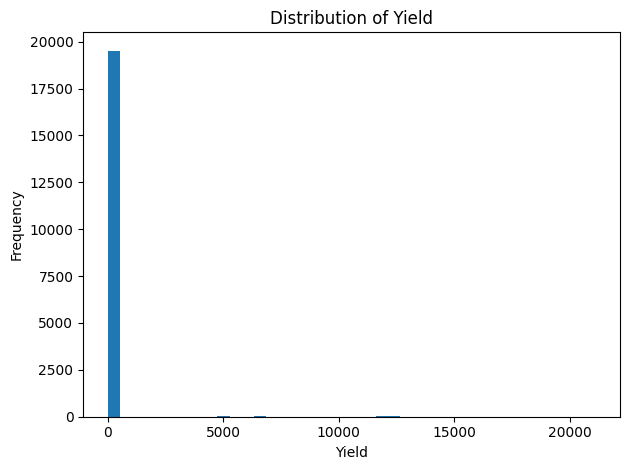


=== Production: Total agricultural output ===


,Production
mean,"16,435,941.273"
median,"13,804.000"
mode,0.000
min,0.000
max,"6,326,000,000.000"
range,"6,326,000,000.000"
q1,"1,393.000"
q3,"122,718.000"
iqr,"121,325.000"
std,"263,056,839.813"


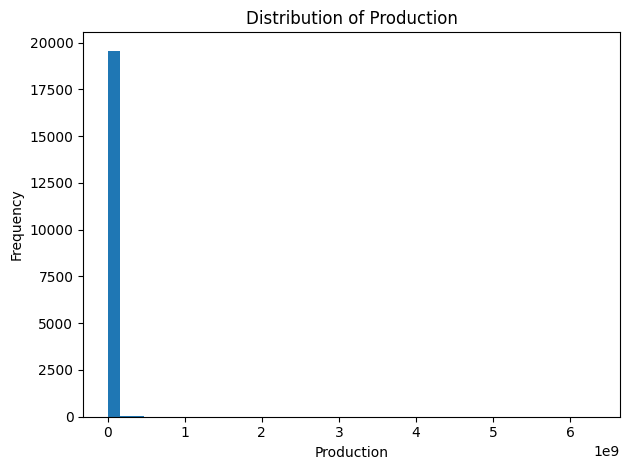


=== CrimeRate_per_100k: Institutional quality proxy (higher crime = weaker institutions) ===


,CrimeRate_per_100k
mean,75.954
median,75.621
mode,18.084
min,18.084
max,136.462
range,118.378
q1,60.343
q3,91.858
iqr,31.515
std,20.198


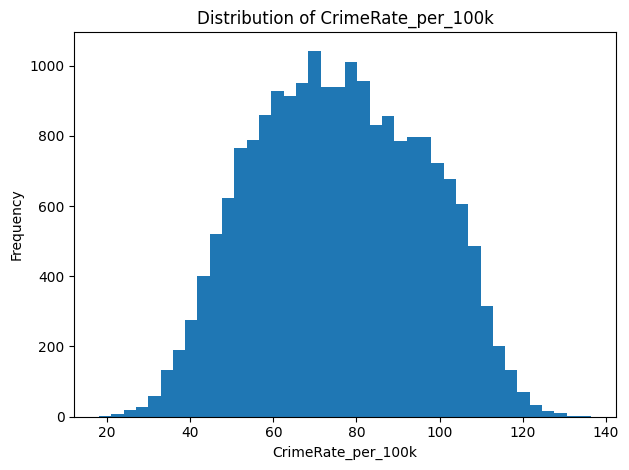

In [3]:
indicators = {
    'Yield': 'Food quality / productivity (output per unit area)',
    'Production': 'Total agricultural output',
    'CrimeRate_per_100k': 'Institutional quality proxy (higher crime = weaker institutions)'
}

def summarize_series(s):
    desc = {
        'mean': s.mean(),
        'median': s.median(),
        'mode': s.mode().iloc[0] if not s.mode().empty else np.nan,
        'min': s.min(),
        'max': s.max(),
        'range': s.max() - s.min(),
        'q1': s.quantile(0.25),
        'q3': s.quantile(0.75),
        'iqr': s.quantile(0.75) - s.quantile(0.25),
        'std': s.std()
    }
    return pd.Series(desc)

summary_tables = {}
for col, desc in indicators.items():
    print(f"\n=== {col}: {desc} ===")
    s = df[col].dropna()
    summary = summarize_series(s)
    display(summary.to_frame(name=col))
    summary_tables[col] = summary

    # Plot distribution (histogram)
    plt.figure()
    plt.hist(s, bins=40)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


In [4]:
# 1) High-crime vs Low-crime states: effect on Yield
high_crime_yield = df.loc[df['HighCrime'] == 1, 'Yield'].dropna()
low_crime_yield = df.loc[df['HighCrime'] == 0, 'Yield'].dropna()
tstat1, pval1 = stats.ttest_ind(high_crime_yield, low_crime_yield, equal_var=False)
print('High-crime vs Low-crime: Yield')
print('t-stat:', tstat1, 'p-value:', pval1)

# 2) Pre-2010 vs Post-2010 Yield (structural change over time)
pre_yield = df.loc[df['Post2010'] == 0, 'Yield'].dropna()
post_yield = df.loc[df['Post2010'] == 1, 'Yield'].dropna()
tstat2, pval2 = stats.ttest_ind(pre_yield, post_yield, equal_var=False)
print('\nPre-2010 vs Post-2010: Yield')
print('t-stat:', tstat2, 'p-value:', pval2)

# 3) Example: Comparing crime rates across two groups of states
treated_states_example = ['Bihar', 'Jharkhand', 'Uttar Pradesh', 'Madhya Pradesh']
df['TreatedExample'] = df['State'].isin(treated_states_example).astype(int)

treated_crime = df.loc[df['TreatedExample'] == 1, 'CrimeRate_per_100k']
control_crime = df.loc[df['TreatedExample'] == 0, 'CrimeRate_per_100k']
tstat3, pval3 = stats.ttest_ind(treated_crime, control_crime, equal_var=False)
print('\nSelected treated vs control states: CrimeRate_per_100k')
print('t-stat:', tstat3, 'p-value:', pval3)

High-crime vs Low-crime: Yield
t-stat: 1.6622014522163282 p-value: 0.0964895149730187

Pre-2010 vs Post-2010: Yield
t-stat: -0.25442075335151365 p-value: 0.7991731929736877

Selected treated vs control states: CrimeRate_per_100k
t-stat: -2.9009951663374376 p-value: 0.0037414346656606656


                    Yield  Production  CrimeRate_per_100k
Yield               1.000       0.571               0.008
Production          0.571       1.000               0.006
CrimeRate_per_100k  0.008       0.006               1.000


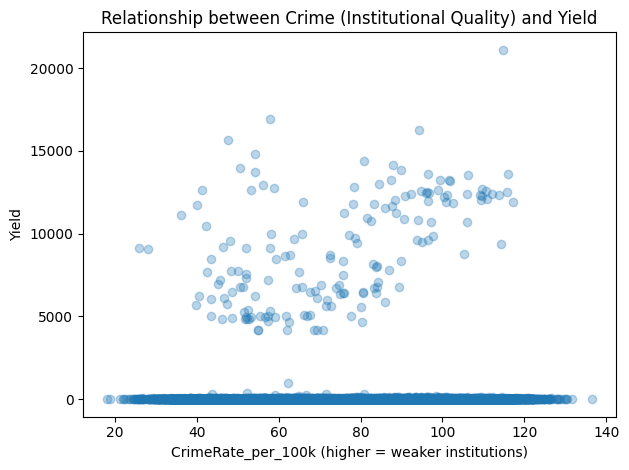

In [5]:
# Correlation matrix between Yield and CrimeRate_per_100k
corr = df[['Yield', 'Production', 'CrimeRate_per_100k']].corr()
print(corr)

# Scatter plot: Crime vs Yield
plt.figure()
plt.scatter(df['CrimeRate_per_100k'], df['Yield'], alpha=0.3)
plt.xlabel('CrimeRate_per_100k (higher = weaker institutions)')
plt.ylabel('Yield')
plt.title('Relationship between Crime (Institutional Quality) and Yield')
plt.tight_layout()
plt.show()


In [6]:
# Difference-in-Differences (DiD) Design
# Define a set of 'treated' states assumed to face a sharp institutional deterioration (higher crime)
treated_states = ['Bihar', 'Jharkhand', 'Uttar Pradesh', 'Madhya Pradesh']

# Aggregate to State-Year level for panel structure
panel = (
    df.groupby(['State', 'Crop_Year'])
      .agg(
          avg_yield=('Yield', 'mean'),
          avg_crime=('CrimeRate_per_100k', 'mean')
      )
      .reset_index()
)

panel['treated'] = panel['State'].isin(treated_states).astype(int)
panel['post'] = (panel['Crop_Year'] >= 2010).astype(int)
panel['did'] = panel['treated'] * panel['post']

panel.head()

,State,Crop_Year,avg_yield,avg_crime,treated,post,did
0,Andhra Pradesh,1997,3.116,39.602,0,0,0
1,Andhra Pradesh,1998,3.407,40.922,0,0,0
2,Andhra Pradesh,1999,3.571,40.404,0,0,0
3,Andhra Pradesh,2000,179.115,40.881,0,0,0
4,Andhra Pradesh,2001,178.332,43.583,0,0,0


                            OLS Regression Results                            
Dep. Variable:              avg_yield   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     4.375
Date:                Tue, 11 Nov 2025   Prob (F-statistic):             0.0117
Time:                        08:53:09   Log-Likelihood:                -4169.3
No. Observations:                 657   AIC:                             8347.
Df Residuals:                     653   BIC:                             8365.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       88.2979     28.319      3.118   

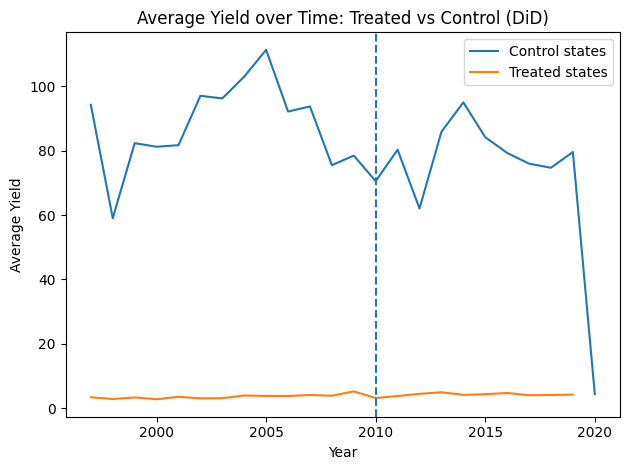

In [7]:
# Run DiD regression: avg_yield ~ treated + post + treated:post
model = smf.ols('avg_yield ~ treated + post + treated:post', data=panel).fit(cov_type='cluster', cov_kwds={'groups': panel['State']})
print(model.summary())

# Plot parallel trends: treated vs control, pre vs post
treated_mean = panel.groupby(['Crop_Year', 'treated'])['avg_yield'].mean().reset_index()

plt.figure()
for t_val, label in [(0, 'Control states'), (1, 'Treated states')]:
    subset = treated_mean[treated_mean['treated'] == t_val]
    plt.plot(subset['Crop_Year'], subset['avg_yield'], label=label)

plt.axvline(2010, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Average Yield')
plt.title('Average Yield over Time: Treated vs Control (DiD)')
plt.legend()
plt.tight_layout()
plt.show()


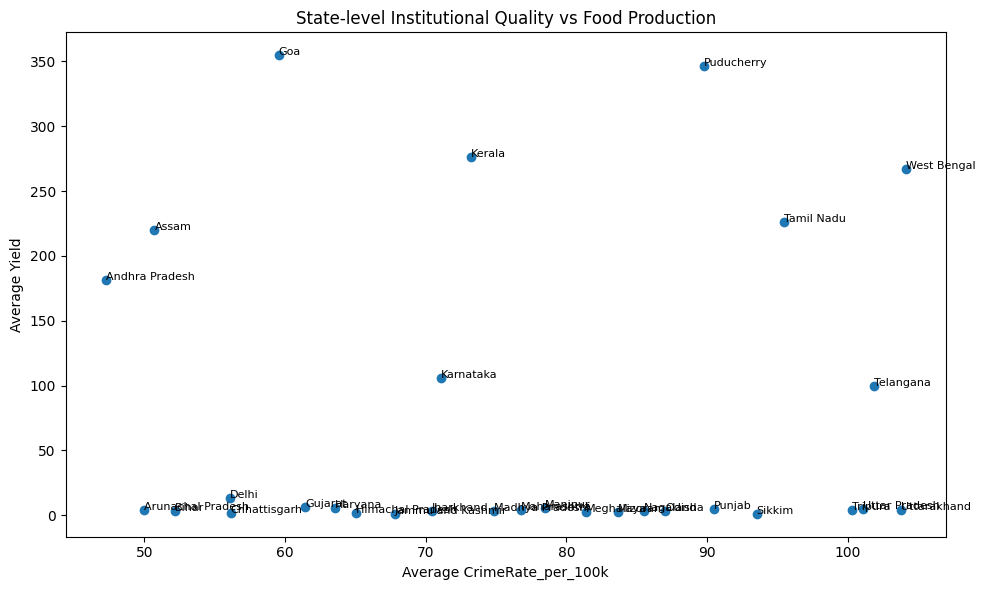

,State,mean_yield,mean_crime
29,West Bengal,266.898,104.105
28,Uttarakhand,3.735,103.779
25,Telangana,99.518,101.890
27,Uttar Pradesh,5.053,101.106
26,Tripura,4.289,100.310


In [8]:
# Additional visualization: cross-sectional comparison by State
state_summary = (
    df.groupby('State')
      .agg(mean_yield=('Yield', 'mean'),
           mean_crime=('CrimeRate_per_100k', 'mean'))
      .reset_index()
)

plt.figure(figsize=(10, 6))
plt.scatter(state_summary['mean_crime'], state_summary['mean_yield'])
for _, row in state_summary.iterrows():
    plt.text(row['mean_crime'], row['mean_yield'], row['State'], fontsize=8)
plt.xlabel('Average CrimeRate_per_100k')
plt.ylabel('Average Yield')
plt.title('State-level Institutional Quality vs Food Production')
plt.tight_layout()
plt.show()

state_summary.sort_values('mean_crime', ascending=False).head()